## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Giovanni Alejandro Castillo Buitrago" # @param {"type":"string"}
carnet = 1000115755 # @param {"type":"integer"}

## 1) Descripción del problema **[1 pts]**

Una empresa necesita organizar los códigos numéricos de los productos que van llegando a la bodega. Estos códigos entran en un orden que no se puede predecir, entonces se necesita una estructura que permita guardarlos y buscarlos de forma eficiente.

Para eso se van a construir dos árboles distintos con exactamente los mismos códigos y en el mismo orden de llegada: un Árbol Binario de Búsqueda (BST) normal, que no se reorganiza después de insertar, y un Árbol AVL, que sí se autobalancea con rotaciones cada vez que un nodo queda desequilibrado. La idea es comparar visualmente cómo queda cada árbol y además poder recorrerlos de tres formas (preorden, inorden y postorden).


## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

**Funcionales:**
- El usuario debe poder indicar cuántos códigos va a registrar y luego ingresarlos uno por uno.
- El sistema debe insertar los códigos en un BST respetando el orden exacto de entrada, sin reorganizar ni balancear nada.
- El sistema debe insertar los mismos códigos, en el mismo orden, en un árbol AVL, aplicando la rotación correspondiente (simple izquierda, simple derecha, doble izquierda-derecha o doble derecha-izquierda) cada vez que un nodo quede desbalanceado.
- El sistema debe calcular el factor de balance de cada nodo del AVL después de cada inserción.
- El sistema debe mostrar gráficamente ambos árboles, dejando claro el nodo raíz, los hijos izquierdos, los hijos derechos y las conexiones entre nodos.
- El sistema debe realizar los recorridos preorden, inorden y postorden sobre los dos árboles y mostrar los resultados.

**No funcionales:**
- La inserción del BST y el balanceo del AVL deben programarse manualmente, sin depender de una librería que ya traiga la estructura armada.
- Los tres recorridos deben implementarse de forma recursiva.
- La visualización gráfica debe ser clara, no basta con imprimir una lista de valores.
- El código debe quedar organizado para poder comparar fácilmente el comportamiento del BST frente al del AVL.


## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.

1. Como encargado de la bodega, quiero ingresar la cantidad de productos y sus códigos, para que el sistema los organice automáticamente en los árboles.
   **Criterio de aceptación:** al ingresar 8 códigos, el sistema los recibe todos y construye tanto el BST como el AVL.

2. Como encargado de la bodega, quiero ver el árbol BST exactamente como queda al insertar los códigos en su orden original, para identificar qué tan desbalanceado puede quedar.
   **Criterio de aceptación:** el árbol mostrado respeta el orden de inserción sin ninguna reorganización.

3. Como encargado de la bodega, quiero ver el árbol AVL ya balanceado con los mismos datos, para comparar visualmente la diferencia frente al BST.
   **Criterio de aceptación:** ningún nodo del árbol AVL queda con un factor de balance mayor a 1 o menor a -1.

4. Como usuario del sistema, quiero obtener los códigos en orden ascendente, para verificar rápidamente si un producto ya está registrado.
   **Criterio de aceptación:** el recorrido inorden del BST devuelve los códigos ordenados de menor a mayor.

5. Como usuario del sistema, quiero ver los tres recorridos (preorden, inorden y postorden) tanto del BST como del AVL, para entender cómo se procesa internamente cada estructura.
   **Criterio de aceptación:** se muestran correctamente los seis resultados (3 recorridos x 2 árboles) sin errores.


## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general

Adjunta imagen y descríbelo claramente.



*** DIAGRAMA GENERAL *** 
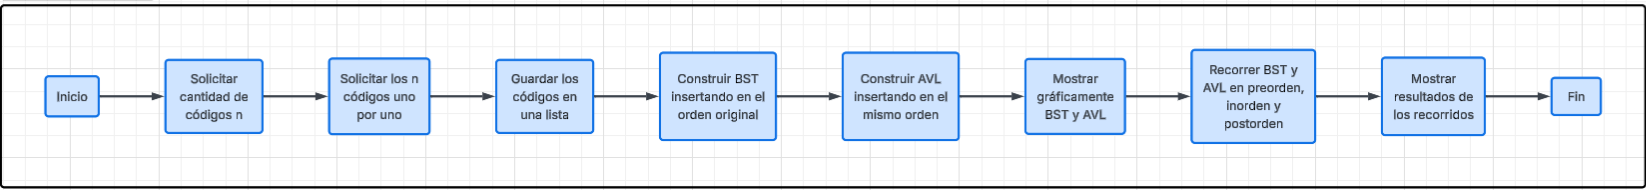

*** DIAGRAMA BST ***

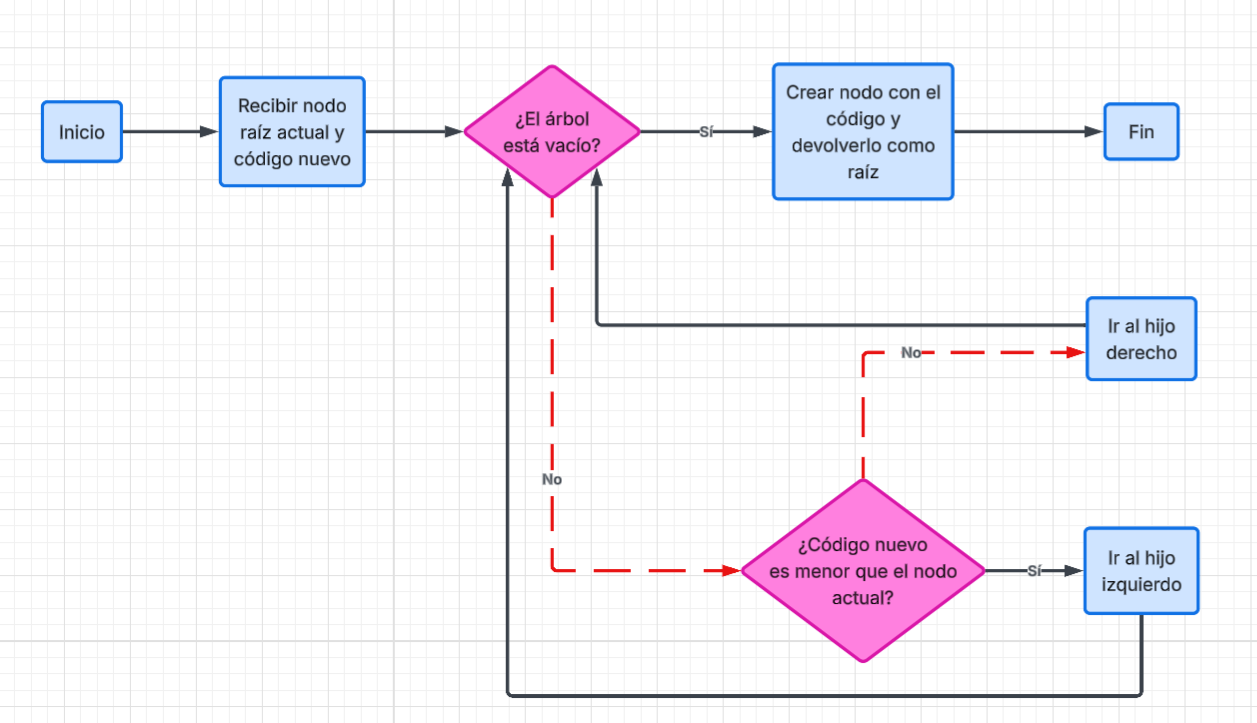

*** DIAGRAMA AVL ***

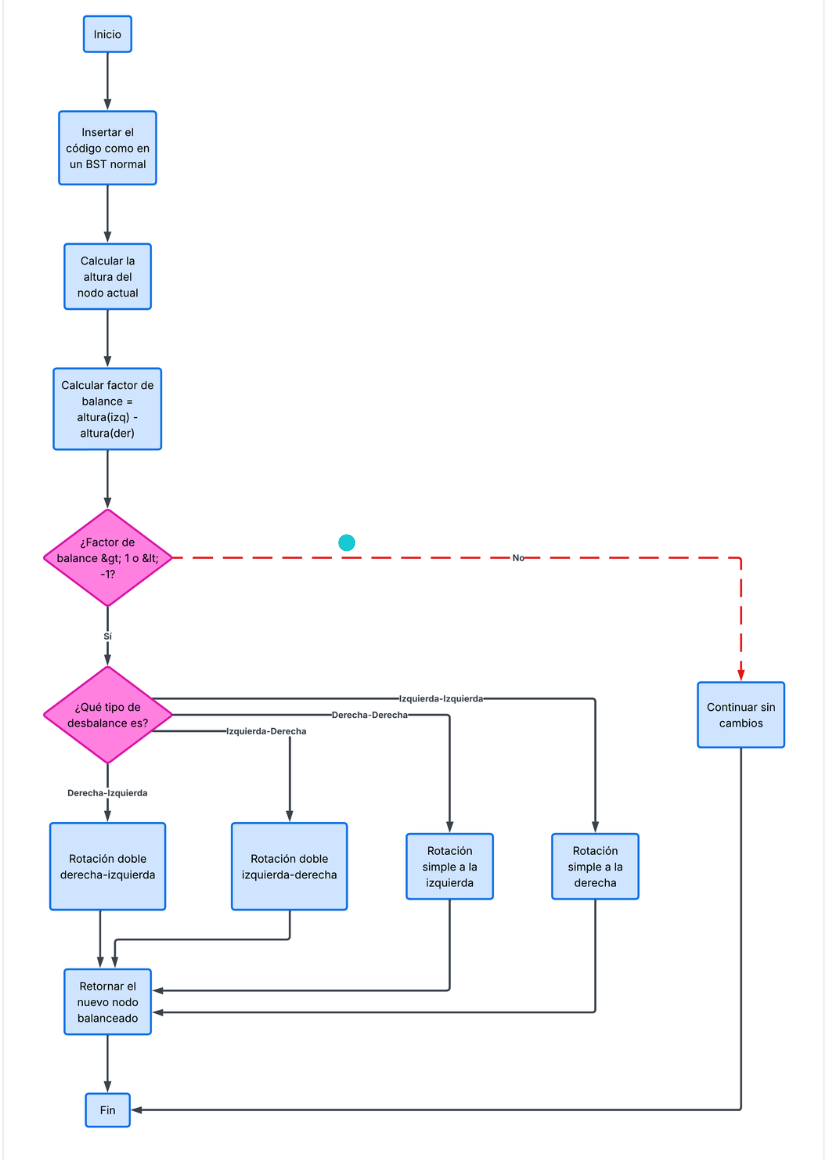

### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica

**Justificación:**

La complejidad de insertar un código en un árbol depende de qué tan profundo (alto) esté el árbol en ese momento, porque insertar implica bajar nivel por nivel comparando el valor nuevo con cada nodo hasta encontrar el lugar correcto. El problema del BST es que, como no se reorganiza, si los códigos llegan en un orden ya ordenado o casi ordenado, el árbol se puede volver prácticamente una lista, haciendo que insertar o buscar se vuelva lento. El AVL, en cambio, se reequilibra solo con rotaciones después de cada inserción, así que su altura siempre se mantiene controlada sin importar el orden en que lleguen los códigos.

**Función T(n):**

Para las inserciones, la complejidad depende de la altura h del árbol:

T(n) = O(h)

- BST: en el peor caso h puede llegar a ser igual a n (árbol degenerado en forma de lista), entonces T(n) = O(n).
- AVL: gracias al balanceo, la altura siempre se mantiene alrededor de log₂(n), entonces T(n) = O(log n), sin importar el orden de los datos.

Para los recorridos (preorden, inorden y postorden), como se visita cada nodo exactamente una vez, la complejidad siempre es:

T(n) = O(n)

**Mejor y peor caso:**

- **BST — mejor caso:** los códigos llegan en un orden que arma un árbol razonablemente equilibrado por casualidad → inserción/búsqueda en O(log n).
- **BST — peor caso:** los códigos llegan ya ordenados (ascendente o descendente) → el árbol se degenera en una especie de lista → inserción/búsqueda en O(n).
- **AVL — mejor y peor caso:** son prácticamente iguales, porque el árbol siempre se reequilibra después de cada inserción → inserción/búsqueda en O(log n) sin importar el orden de entrada.

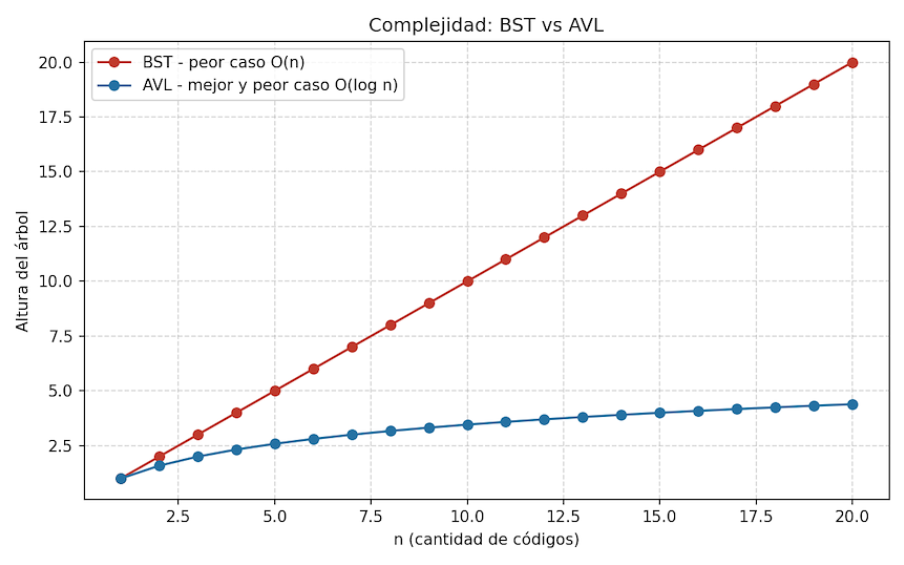


## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:
# 6.1 Estructura del nodo, BST, AVL y recorridos

class Nodo:
    def __init__(self, p_valor):
        self.valor = p_valor
        self.izq = None
        self.der = None
        self.altura = 1         


def altura(p_nodo):
    resultado = 0
    if p_nodo != None:
        resultado = p_nodo.altura
    return resultado

def actualizarAltura(p_nodo):
    alturaIzq = altura(p_nodo.izq)
    alturaDer = altura(p_nodo.der)
    if alturaIzq > alturaDer:
        p_nodo.altura = 1 + alturaIzq
    else:
        p_nodo.altura = 1 + alturaDer

def factorBalance(p_nodo):
    resultado = 0
    if p_nodo != None:
        resultado = altura(p_nodo.izq) - altura(p_nodo.der)
    return resultado

def imprimirFactores(p_raiz):
    if p_raiz != None:
        imprimirFactores(p_raiz.izq)
        print("   nodo", p_raiz.valor, "-> factor de balance =", factorBalance(p_raiz))
        imprimirFactores(p_raiz.der)


def insertarBST(p_raiz, p_valor):
    if p_raiz == None:
        resultado = Nodo(p_valor)
    else:
        if p_valor < p_raiz.valor:
            p_raiz.izq = insertarBST(p_raiz.izq, p_valor)
        else:
            if p_valor > p_raiz.valor:
                p_raiz.der = insertarBST(p_raiz.der, p_valor)
        actualizarAltura(p_raiz)
        resultado = p_raiz
    return resultado

def construirBST(p_codigos):
    raiz = None
    for i in range(len(p_codigos)):
        raiz = insertarBST(raiz, p_codigos[i])
    return raiz

def rotarDerecha(p_y):
    x = p_y.izq
    p_y.izq = x.der
    x.der = p_y
    actualizarAltura(p_y)
    actualizarAltura(x)
    return x

def rotarIzquierda(p_x):
    y = p_x.der
    p_x.der = y.izq
    y.izq = p_x
    actualizarAltura(p_x)
    actualizarAltura(y)
    return y

def balancear(p_nodo, p_mostrar=0):
    fb = factorBalance(p_nodo)
    resultado = p_nodo
    if fb > 1:
        if factorBalance(p_nodo.izq) >= 0:
            if p_mostrar == 1:
                print("   Desbalance en " + str(p_nodo.valor) + " (fb = " + str(fb) + ") -> rotación simple a la derecha")
            resultado = rotarDerecha(p_nodo)
        else:
            if p_mostrar == 1:
                print("   Desbalance en " + str(p_nodo.valor) + " (fb = " + str(fb) + ") -> rotación doble izquierda-derecha")
            p_nodo.izq = rotarIzquierda(p_nodo.izq)
            resultado = rotarDerecha(p_nodo)
    else:
        if fb < -1:
            if factorBalance(p_nodo.der) <= 0:
                if p_mostrar == 1:
                    print("   Desbalance en " + str(p_nodo.valor) + " (fb = " + str(fb) + ") -> rotación simple a la izquierda")
                resultado = rotarIzquierda(p_nodo)
            else:
                if p_mostrar == 1:
                    print("   Desbalance en " + str(p_nodo.valor) + " (fb = " + str(fb) + ") -> rotación doble derecha-izquierda")
                p_nodo.der = rotarDerecha(p_nodo.der)
                resultado = rotarIzquierda(p_nodo)
    return resultado

def insertarAVL(p_raiz, p_valor, p_mostrar=0):
    if p_raiz == None:
        resultado = Nodo(p_valor)
    else:
        if p_valor < p_raiz.valor:
            p_raiz.izq = insertarAVL(p_raiz.izq, p_valor, p_mostrar)
        else:
            if p_valor > p_raiz.valor:
                p_raiz.der = insertarAVL(p_raiz.der, p_valor, p_mostrar)
        actualizarAltura(p_raiz)
        resultado = balancear(p_raiz, p_mostrar)
    return resultado

def construirAVL(p_codigos, p_mostrar=0):
    raiz = None
    for i in range(len(p_codigos)):
        raiz = insertarAVL(raiz, p_codigos[i], p_mostrar)
    return raiz

def preorden(p_raiz):
    resultado = []
    if p_raiz != None:
        resultado = [p_raiz.valor] + preorden(p_raiz.izq) + preorden(p_raiz.der)
    return resultado

def inorden(p_raiz):
    resultado = []
    if p_raiz != None:
        resultado = inorden(p_raiz.izq) + [p_raiz.valor] + inorden(p_raiz.der)
    return resultado

def postorden(p_raiz):
    resultado = []
    if p_raiz != None:
        resultado = postorden(p_raiz.izq) + postorden(p_raiz.der) + [p_raiz.valor]
    return resultado

def estaOrdenada(p_lista):
    resultado = 1
    for i in range(len(p_lista) - 1):
        if p_lista[i] >= p_lista[i + 1]:
            resultado = 0
    return resultado

In [ ]:

import matplotlib.pyplot as plt

def dibujarNodo(p_ax, p_nodo, p_nivel, p_ordenados, p_color, p_xPadre, p_yPadre):
    if p_nodo != None:
        x = 0
        for i in range(len(p_ordenados)):
            if p_ordenados[i] == p_nodo.valor:
                x = i
        y = -p_nivel
        if p_nivel > 0:
            p_ax.plot([p_xPadre, x], [p_yPadre, y], color="black", linewidth=1.5, zorder=1)
        p_ax.scatter([x], [y], s=1100, color=p_color, edgecolors="black", zorder=3)
        p_ax.text(x, y, str(p_nodo.valor), ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)
        p_ax.text(x, y - 0.33, "fb=" + str(factorBalance(p_nodo)), ha="center", va="center",
                  fontsize=8, color="dimgray", zorder=4,
                  bbox=dict(facecolor="white", edgecolor="none", pad=0.6))
        dibujarNodo(p_ax, p_nodo.izq, p_nivel + 1, p_ordenados, "lightskyblue", x, y)
        dibujarNodo(p_ax, p_nodo.der, p_nivel + 1, p_ordenados, "lightgreen", x, y)

def dibujarArbol(p_ax, p_raiz, p_titulo):
    ordenados = inorden(p_raiz)
    dibujarNodo(p_ax, p_raiz, 0, ordenados, "gold", 0, 0)
    p_ax.scatter([], [], s=150, color="gold", edgecolors="black", label="Raíz")
    p_ax.scatter([], [], s=150, color="lightskyblue", edgecolors="black", label="Hijo izquierdo")
    p_ax.scatter([], [], s=150, color="lightgreen", edgecolors="black", label="Hijo derecho")
    p_ax.set_xlim(-1, len(ordenados))
    p_ax.set_ylim(-altura(p_raiz) - 0.2, 0.8)
    p_ax.set_title(p_titulo + " (altura = " + str(altura(p_raiz)) + ")", fontsize=13)
    p_ax.legend(loc="lower center", ncol=3, fontsize=8, frameon=False)
    p_ax.axis("off")

def mostrarArboles(p_bst, p_avl):
    alturaMayor = altura(p_bst)
    if altura(p_avl) > alturaMayor:
        alturaMayor = altura(p_avl)
    cantidad = len(inorden(p_bst))
    figura, ejes = plt.subplots(1, 2, figsize=(max(14, 1.6 * cantidad), max(6, alturaMayor + 2)))
    dibujarArbol(ejes[0], p_bst, "Árbol Binario de Búsqueda (BST)")
    dibujarArbol(ejes[1], p_avl, "Árbol AVL")
    plt.tight_layout()
    plt.show()

In [ ]:

def ejecutarPrograma(p_codigos):
    print("Códigos ingresados:", p_codigos)
    print()

    bst = construirBST(p_codigos)
    print("=== BST (sin balancear) ===")
    print("Altura:", altura(bst), "| Factor de balance de la raíz:", factorBalance(bst))
    print("Factor de balance de cada nodo:")
    imprimirFactores(bst)
    print()

    print("=== Construcción del AVL ===")
    avl = None
    for i in range(len(p_codigos)):
        print("Insertando", p_codigos[i])
        avl = insertarAVL(avl, p_codigos[i], 1)
        print("   raíz =", avl.valor, "| altura =", altura(avl), "| factor de balance de la raíz =", factorBalance(avl))
    print()
    print("Factor de balance de cada nodo del AVL final:")
    imprimirFactores(avl)
    print()

    mostrarArboles(bst, avl)

    print("=== Recorridos ===")
    print("BST - Preorden :", preorden(bst))
    print("AVL - Preorden :", preorden(avl))
    print("BST - Inorden  :", inorden(bst))
    print("AVL - Inorden  :", inorden(avl))
    print("BST - Postorden:", postorden(bst))
    print("AVL - Postorden:", postorden(avl))
    print()

    print("=== Comparación ===")
    print("Altura BST:", altura(bst), "| Altura AVL:", altura(avl))
    if estaOrdenada(inorden(bst)) == 1:
        print("El inorden del BST quedó ordenado de menor a mayor.")
    if inorden(bst) == inorden(avl):
        print("El inorden del BST y del AVL es el mismo, aunque los árboles tengan forma distinta.")

def estaRepetido(p_lista, p_cantidad, p_valor):
    resultado = 0
    for i in range(p_cantidad):
        if p_lista[i] == p_valor:
            resultado = 1
    return resultado

texto = input("Ingrese la cantidad de productos: ")
while not texto.isdigit() or int(texto) <= 0:
    print("Debe ser un número entero mayor que 0.")
    texto = input("Ingrese la cantidad de productos: ")
n = int(texto)

codigos = [0] * n
i = 0
while i < n:
    texto = input("Ingrese el código " + str(i + 1) + ": ")
    if not texto.isdigit():
        print("El código debe ser un número entero positivo.")
    else:
        if estaRepetido(codigos, i, int(texto)) == 1:
            print("Ese código ya fue ingresado, escriba otro.")
        else:
            codigos[i] = int(texto)
            i = i + 1

ejecutarPrograma(codigos)

### Análisis: ¿qué característica tiene el recorrido inorden en un BST?

En un BST, para cada nodo todo lo que está en su subárbol izquierdo es menor que él y todo lo que está en el derecho es mayor. El inorden visita primero el subárbol izquierdo, luego el nodo y luego el derecho, o sea que saca primero los menores, después el nodo y al final los mayores. Como esto se cumple en todos los nodos del árbol, el resultado siempre sale **ordenado de menor a mayor**, sin importar el orden en que se ingresaron los códigos ni la forma que tenga el árbol.

Por eso el BST y el AVL con los mismos códigos dan el mismo inorden (`[5, 10, 20, 25, 27, 28, 30, 50]`) aunque sus formas sean distintas. También significa que insertar los códigos en un BST y recorrerlo en inorden es una forma de ordenarlos. En cambio, el preorden y el postorden sí dependen de la forma del árbol, por eso cambian entre el BST y el AVL.

## 7) Tests aplicados **[15 pts]**

Casos de prueba con sus resultados esperados. La celda de abajo los verifica con `assert`; si alguno falla, Python muestra el error, y si todo está bien imprime "Todos los tests pasaron". Estos tests usan las funciones de la sección 6 (hay que ejecutar primero esas celdas) y no piden datos por teclado.

| # | Caso | Entrada | Resultado esperado |
|---|---|---|---|
| 1 | BST con los datos del enunciado | `[30, 20, 10, 25, 28, 27, 5, 50]` | preorden `[30, 20, 10, 5, 25, 28, 27, 50]`, inorden `[5, 10, 20, 25, 27, 28, 30, 50]`, postorden `[5, 10, 27, 28, 25, 20, 50, 30]` |
| 2 | AVL con los datos del enunciado | `[30, 20, 10, 25, 28, 27, 5, 50]` | preorden `[25, 10, 5, 20, 28, 27, 30, 50]`, inorden `[5, 10, 20, 25, 27, 28, 30, 50]`, postorden `[5, 20, 10, 27, 50, 30, 28, 25]` |
| 3 | Alturas y factores de balance | los mismos datos | BST: altura 5 y factor de balance de la raíz 3 (no es AVL). AVL: altura 4, raíz -1 y todos los nodos entre -1 y 1 |
| 4 | Inorden de ambos árboles | los mismos datos | igual en los dos y ordenado de menor a mayor; el preorden del BST no sale ordenado |
| 5 | Las cuatro rotaciones | `[30, 20, 10]`, `[10, 20, 30]`, `[30, 10, 20]`, `[10, 30, 20]` | el AVL siempre queda con preorden `[20, 10, 30]`; el BST no se reorganiza (`[30, 20, 10]` y `[10, 20, 30]`) |
| 6 | Peor caso del BST | `[1..7]` ascendente y descendente | BST altura 7, AVL altura 3 y preorden `[4, 2, 1, 3, 6, 5, 7]` |
| 7 | Casos borde | árbol vacío y un solo código `[42]` | recorridos `[]` para el árbol vacío y altura 0; con un código, `[42]` y altura 1 |
| 8 | 20 códigos en orden revuelto | `(i * 7) % 20` para i de 0 a 19 | inorden `[0, 1, ..., 19]` en ambos, el AVL cumple el balance en todos sus nodos y su altura es menor o igual a la del BST |
| 9 | Códigos repetidos | `[5, 5, 5]` y `[20, 10, 20, 10, 30]` | el código repetido se ignora: `[5]` y `[20, 10, 30]` |

In [ ]:
# Tests aplicados
# Se usan las funciones de la sección 6 (no se pide ningún dato por teclado).

def esAVL(p_raiz):
    resultado = 1
    if p_raiz != None:
        fb = factorBalance(p_raiz)
        if fb < -1 or fb > 1:
            resultado = 0
        resultado = resultado * esAVL(p_raiz.izq) * esAVL(p_raiz.der)
    return resultado

codigos = [30, 20, 10, 25, 28, 27, 5, 50]
bst = construirBST(codigos)
avl = construirAVL(codigos)

assert preorden(bst) == [30, 20, 10, 5, 25, 28, 27, 50]
assert inorden(bst) == [5, 10, 20, 25, 27, 28, 30, 50]
assert postorden(bst) == [5, 10, 27, 28, 25, 20, 50, 30]

assert preorden(avl) == [25, 10, 5, 20, 28, 27, 30, 50]
assert inorden(avl) == [5, 10, 20, 25, 27, 28, 30, 50]
assert postorden(avl) == [5, 20, 10, 27, 50, 30, 28, 25]

assert altura(bst) == 5 and altura(avl) == 4
assert factorBalance(bst) == 3      
assert factorBalance(avl) == -1
assert esAVL(bst) == 0
assert esAVL(avl) == 1

assert inorden(bst) == inorden(avl)
assert estaOrdenada(inorden(bst)) == 1
assert estaOrdenada(inorden(avl)) == 1
assert estaOrdenada(preorden(bst)) == 0     

assert preorden(construirAVL([30, 20, 10])) == [20, 10, 30]   # simple a la derecha (LL)
assert preorden(construirAVL([10, 20, 30])) == [20, 10, 30]   # simple a la izquierda (RR)
assert preorden(construirAVL([30, 10, 20])) == [20, 10, 30]   # doble izquierda-derecha (LR)
assert preorden(construirAVL([10, 30, 20])) == [20, 10, 30]   # doble derecha-izquierda (RL)
assert preorden(construirBST([30, 20, 10])) == [30, 20, 10]
assert preorden(construirBST([10, 20, 30])) == [10, 20, 30]

ascendente = [0]*7
descendente = [0]*7
for i in range(7):
    ascendente[i] = i + 1
    descendente[i] = 7 - i
assert altura(construirBST(ascendente)) == 7      # se vuelve una lista enlazada
assert altura(construirBST(descendente)) == 7
assert altura(construirAVL(ascendente)) == 3      # el AVL lo mantiene balanceado
assert preorden(construirAVL(ascendente)) == [4, 2, 1, 3, 6, 5, 7]
assert preorden(construirAVL(descendente)) == [4, 2, 1, 3, 6, 5, 7]

# --- Test 7: casos borde ---
assert preorden(None) == [] and inorden(None) == [] and postorden(None) == []
assert altura(None) == 0
assert preorden(construirBST([42])) == [42]
assert preorden(construirAVL([42])) == [42]
assert altura(construirAVL([42])) == 1

revueltos = [0]*20
esperado = [0]*20
for i in range(20):
    revueltos[i] = (i * 7) % 20
    esperado[i] = i
avl20 = construirAVL(revueltos)
bst20 = construirBST(revueltos)
assert inorden(avl20) == esperado
assert inorden(bst20) == esperado
assert esAVL(avl20) == 1
assert altura(avl20) <= altura(bst20)

assert preorden(construirBST([5, 5, 5])) == [5]
assert preorden(construirAVL([20, 10, 20, 10, 30])) == [20, 10, 30]

print("Todos los tests pasaron")